# Quantum Walk Search Toy Model

This notebook studies continuous-time quantum walk search on a complete graph. The Hamiltonian is

$$H=-\gamma A-|m\rangle\langle m|,$$

where `A` is the graph adjacency matrix and `|m>` is the marked vertex. Starting from the uniform state, the marked-vertex probability rises close to one. We also approximate the time-evolution phase response with real and imaginary spectral polynomials.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a continuous-time search problem on a complete graph with one marked vertex.

**QSVT implementation.** It approximates the search propagator by polynomial real and imaginary phase components. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral evolution validates the marked-vertex probability. The notebook illustrates the polynomial-transform view of quantum walk search, while the tiny graph is chosen for transparent validation rather than speed.


## Variable definitions

- `n_vertices`: number of vertices in the complete graph.
- `marked`: index of the marked vertex.
- `gamma`: hopping/search rate.
- `adjacency`: complete-graph adjacency matrix.
- `H`: search Hamiltonian.
- `start`: uniform initial state.
- `eigenvalues`: exact eigenvalues of `H`.
- `center`, `half_width`: midpoint and half-width of the spectrum.
- `A`: rescaled Hamiltonian.
- `times`: search-time grid.
- `probabilities`: marked-vertex probabilities over time.
- `U`, `state`: exact propagator and state at one time.
- `best_index`, `best_time`, `best_probability`: best sampled search time and success probability.
- `fit_x`, `phase`: fitting grid and exact phase target.
- `real_coeffs`, `imag_coeffs`: polynomial coefficients for real and imaginary propagator parts.
- `U_poly`, `state_poly`, `U_exact`, `state_exact`: polynomial/exact propagators and states.
- `state_error`, `poly_probability`: final validation metrics.
- `fig`, `axes`, `angles`, `pos`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)

np.set_printoptions(precision=4, suppress=True)

In [2]:
n_vertices = 8
marked = 0
gamma = 1.0 / n_vertices

adjacency = np.ones((n_vertices, n_vertices)) - np.eye(n_vertices)
H = -gamma * adjacency
H[marked, marked] -= 1.0

start = np.ones(n_vertices, dtype=complex) / np.sqrt(n_vertices)
eigenvalues, _ = eigh_hermitian(H)

center = 0.5 * (eigenvalues[0] + eigenvalues[-1])
half_width = 0.5 * (eigenvalues[-1] - eigenvalues[0])
A = (H - center * np.eye(n_vertices)) / half_width

print(f"Eigenvalues [oracle energy units]: {eigenvalues}")
print(f"Eigenvalues of A: {np.linalg.eigvalsh(A)[[0, -1]]}")

Eigenvalues [oracle energy units]: [-1.2286 -0.5214  0.125   0.125   0.125   0.125   0.125   0.125 ]
Eigenvalues of A: [-1.  1.]


## Search graph schematic

The continuous-time search Hamiltonian uses a complete graph with one marked vertex carrying an oracle shift.


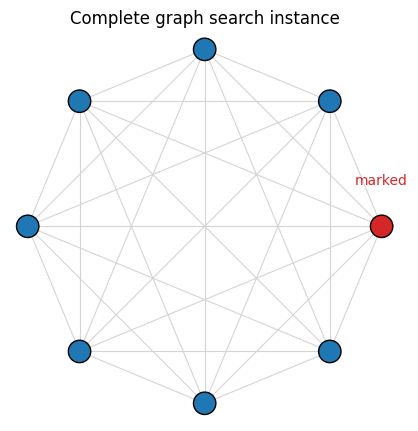

In [3]:
fig, ax = plt.subplots(figsize=(4.6, 4.2), constrained_layout=True)

angles = np.linspace(0, 2 * np.pi, n_vertices, endpoint=False)
pos = np.c_[np.cos(angles), np.sin(angles)]
for i in range(n_vertices):
    for j in range(i + 1, n_vertices):
        ax.plot(
            [pos[i, 0], pos[j, 0]],
            [pos[i, 1], pos[j, 1]],
            color="0.83",
            linewidth=0.8,
            zorder=1,
        )
colors = ["tab:red" if i == marked else "tab:blue" for i in range(n_vertices)]
ax.scatter(pos[:, 0], pos[:, 1], s=260, color=colors, edgecolor="black", zorder=3)
ax.text(pos[marked, 0], pos[marked, 1] + 0.24, "marked", ha="center", color="tab:red")
ax.set_title("Complete graph search instance")
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Exact search dynamics

The probability at the marked vertex is computed by exact spectral time evolution.

In [4]:
times = np.linspace(0.0, 12.0, 160)
probabilities = []
for t in times:
    U = apply_function_to_hermitian(H, lambda lam: np.exp(-1.0j * t * lam))
    state = U @ start
    probabilities.append(np.abs(state[marked]) ** 2)

probabilities = np.array(probabilities)
best_index = int(np.argmax(probabilities))
best_time = times[best_index]
best_probability = probabilities[best_index]

print(f"Best Time [inverse energy units]: {best_time}")
print(f"Best Probability [probability]: {best_probability}")

Best Time [inverse energy units]: 4.452830188679245
Best Probability [probability]: 0.9999891776297675


## Polynomial phase approximation

For the best search time, fit real polynomials to the real and imaginary parts of the phase `exp(-i t (center + half_width*x))` on `[-1, 1]`.

In [5]:
degree = 18
fit_x = np.linspace(-1.0, 1.0, 1201)
phase = np.exp(-1.0j * best_time * (center + half_width * fit_x))

real_coeffs = np.polynomial.polynomial.polyfit(fit_x, phase.real, degree)
imag_coeffs = np.polynomial.polynomial.polyfit(fit_x, phase.imag, degree)

U_poly = apply_polynomial_to_hermitian(A, real_coeffs)
U_poly = U_poly + 1.0j * apply_polynomial_to_hermitian(A, imag_coeffs)
state_poly = U_poly @ start

U_exact = apply_function_to_hermitian(H, lambda lam: np.exp(-1.0j * best_time * lam))
state_exact = U_exact @ start

state_error = np.linalg.norm(state_poly - state_exact)
poly_probability = np.abs(state_poly[marked]) ** 2
print(f"State Error: {state_error}")
print(f"Polynomial Probability [probability]: {poly_probability}")

State Error: 1.0120998885188465e-13
Polynomial Probability [probability]: 0.9999891776298157


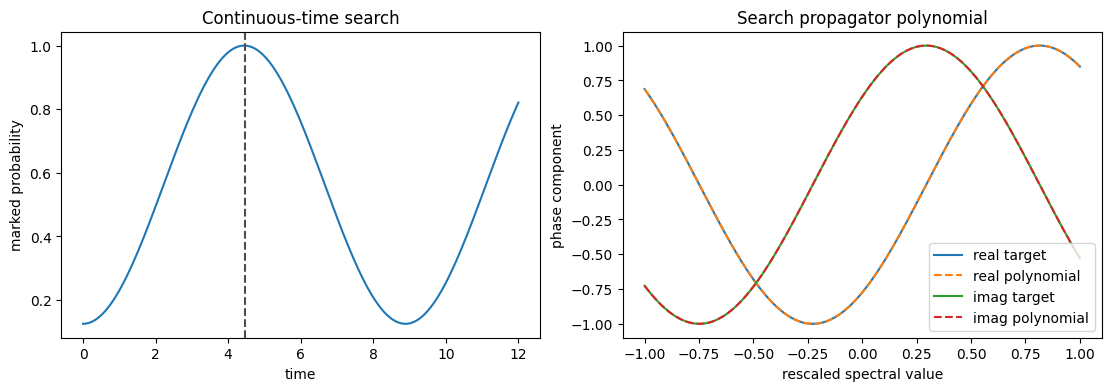

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)

axes[0].plot(times, probabilities)
axes[0].axvline(best_time, color="0.3", linestyle="--")
axes[0].set_xlabel("time")
axes[0].set_ylabel("marked probability")
axes[0].set_title("Continuous-time search")

plot_x = np.linspace(-1.0, 1.0, 500)
plot_phase = np.exp(-1.0j * best_time * (center + half_width * plot_x))
axes[1].plot(plot_x, plot_phase.real, label="real target")
axes[1].plot(
    plot_x, eval_polynomial(real_coeffs, plot_x), "--", label="real polynomial"
)
axes[1].plot(plot_x, plot_phase.imag, label="imag target")
axes[1].plot(
    plot_x, eval_polynomial(imag_coeffs, plot_x), "--", label="imag polynomial"
)
axes[1].set_xlabel("rescaled spectral value")
axes[1].set_ylabel("phase component")
axes[1].set_title("Search propagator polynomial")
axes[1].legend()

plt.show()

## Validation

Compact checks for the expected numerical behavior.

In [7]:
assert best_probability > 0.95
assert np.isfinite(state_error)
assert state_error < 1e-8
assert abs(poly_probability - best_probability) < 1e-8

print(f"best_time [inverse energy units]: {best_time:.3f}")
print(f"best_probability [probability]: {best_probability:.6f}")
print(f"poly_probability [probability]: {poly_probability:.6f}")
print(f"state_error: {state_error:.3e}")
print("validation: passed")

best_time [inverse energy units]: 4.453
best_probability [probability]: 0.999989
poly_probability [probability]: 0.999989
state_error: 1.012e-13
validation: passed
